In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score,
                             recall_score, f1_score)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from tqdm import tqdm

print("Libraries loaded")
print("PyTorch version:", torch.__version__)

Libraries loaded
PyTorch version: 2.10.0+cpu


In [2]:
import zipfile

zip_path    = "tdcsfog.zip"
extract_path = "tdcsfog_csvs"

with zipfile.ZipFile(zip_path, 'r') as zf:
    zf.extractall(extract_path)

csv_files = [
    os.path.join(extract_path, f)
    for f in os.listdir(extract_path)
    if f.endswith(".csv")
]

print(f"Total CSV files: {len(csv_files)}")

sample_df = pd.read_csv(csv_files[0])
print("\nColumns:", sample_df.columns.tolist())
print(f"Rows in sample file: {len(sample_df)}")
print(sample_df.head())

Total CSV files: 833

Columns: ['Time', 'AccV', 'AccML', 'AccAP', 'StartHesitation', 'Turn', 'Walking']
Rows in sample file: 8693
   Time      AccV     AccML     AccAP  StartHesitation  Turn  Walking
0     0 -9.047162  1.024580 -3.153285                0     0        0
1     1 -9.036154  1.030939 -3.144462                0     0        0
2     2 -9.040541  1.024287 -3.164779                0     0        0
3     3 -9.054033  1.031446 -3.162322                0     0        0
4     4 -9.040534  1.033479 -3.166850                0     0        0


In [3]:
FS          = 128   # Hz — 128 samples = 1 second
WINDOW_SIZE = 192   # samples = 1.5 seconds
STEP        = 128   # samples = 1.0 second (0.5s overlap)
FOG_THRESH_HIGH = 0.6   # window is FOG if >= 60% samples are FOG
FOG_THRESH_LOW  = 0.4   # window is non-FOG if <= 40% samples are FOG

print(f"Window duration : {WINDOW_SIZE/FS:.2f} s")
print(f"Step duration   : {STEP/FS:.2f} s")
print(f"Overlap         : {(WINDOW_SIZE-STEP)/FS:.2f} s")

Window duration : 1.50 s
Step duration   : 1.00 s
Overlap         : 0.50 s


In [4]:
def extract_windows(df, fs=FS, window_size=WINDOW_SIZE, step=STEP):
    """
    Slide a window over one subject's CSV.
    Returns:
        X        : (N, window_size, 3)  raw accelerometer windows
        y        : (N,)                 binary FOG label per window
        t_starts : (N,)                 window start in SECONDS
        t_ends   : (N,)                 window end   in SECONDS
    """
    # FOG = any of the three event columns is active
    df = df.copy()
    df["FOG"] = (
        (df["StartHesitation"] == 1) |
        (df["Turn"]            == 1) |
        (df["Walking"]         == 1)
    ).astype(int)

    signals    = df[["AccV", "AccML", "AccAP"]].values   # (T, 3)
    fog_labels = df["FOG"].values                         # (T,)
    T          = len(df)

    X, y, t_starts, t_ends = [], [], [], []

    for start in range(0, T - window_size, step):
        end = start + window_size

        fog_ratio = fog_labels[start:end].mean()

        if fog_ratio >= FOG_THRESH_HIGH:
            label = 1
        elif fog_ratio <= FOG_THRESH_LOW:
            label = 0
        else:
            continue   # ambiguous window — skip

        X.append(signals[start:end])
        y.append(label)
        t_starts.append(start / fs)   # convert sample index → seconds
        t_ends.append(end   / fs)

    return (np.array(X, dtype=np.float32),
            np.array(y, dtype=np.int8),
            np.array(t_starts, dtype=np.float32),
            np.array(t_ends,   dtype=np.float32))

In [5]:
X_list, y_list        = [], []
subj_list             = []
t_start_list, t_end_list = [], []

for path in tqdm(csv_files, desc="Processing subjects"):
    df = pd.read_csv(path)
    X, y, t_starts, t_ends = extract_windows(df)

    if len(y) == 0:
        continue

    subject_id = os.path.basename(path).replace(".csv", "")

    X_list.append(X)
    y_list.append(y)
    subj_list.extend([subject_id] * len(y))
    t_start_list.extend(t_starts)
    t_end_list.extend(t_ends)

X_all       = np.concatenate(X_list,  axis=0)
y_all       = np.concatenate(y_list,  axis=0)
subject_ids = np.array(subj_list)
t_start_all = np.array(t_start_list, dtype=np.float32)
t_end_all   = np.array(t_end_list,   dtype=np.float32)

print(f"X shape        : {X_all.shape}")        # (N, 192, 3)
print(f"y shape        : {y_all.shape}")
print(f"Unique subjects: {len(np.unique(subject_ids))}")
print(f"FOG ratio      : {y_all.mean():.4f}")

Processing subjects: 100%|██████████| 833/833 [00:14<00:00, 55.64it/s]


X shape        : (53654, 192, 3)
y shape        : (53654,)
Unique subjects: 833
FOG ratio      : 0.3128


In [6]:
unique_subjects = np.unique(subject_ids)
print(f"Total unique subjects: {len(unique_subjects)}")

# 70% train | 15% val | 15% test — split on SUBJECT IDs, not windows
train_subj, temp_subj = train_test_split(
    unique_subjects, test_size=0.30, random_state=42
)
val_subj, test_subj = train_test_split(
    temp_subj, test_size=0.50, random_state=42
)

train_mask = np.isin(subject_ids, train_subj)
val_mask   = np.isin(subject_ids, val_subj)
test_mask  = np.isin(subject_ids, test_subj)

X_train,  y_train  = X_all[train_mask], y_all[train_mask]
X_val,    y_val    = X_all[val_mask],   y_all[val_mask]
X_test,   y_test   = X_all[test_mask],  y_all[test_mask]

t_start_test = t_start_all[test_mask]
t_end_test   = t_end_all[test_mask]
subj_test    = subject_ids[test_mask]

print(f"Train windows : {len(y_train)}  |  FOG: {y_train.mean():.3f}")
print(f"Val   windows : {len(y_val)}  |  FOG: {y_val.mean():.3f}")
print(f"Test  windows : {len(y_test)}  |  FOG: {y_test.mean():.3f}")

Total unique subjects: 833
Train windows : 35576  |  FOG: 0.260
Val   windows : 8665  |  FOG: 0.388
Test  windows : 9413  |  FOG: 0.441


In [7]:
class FoGDataset(Dataset):
    def __init__(self, X, y):
        # Store as tensors; normalisation happens in __getitem__
        self.X = torch.tensor(X, dtype=torch.float32)   # (N, 192, 3)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx]                              # (192, 3)
        # Per-channel z-score normalisation per window
        mean = x.mean(dim=0, keepdim=True)           # (1, 3)
        std  = x.std(dim=0,  keepdim=True) + 1e-8
        x    = (x - mean) / std
        return x, self.y[idx]


BATCH_SIZE = 64

train_loader = DataLoader(FoGDataset(X_train, y_train),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(FoGDataset(X_val,   y_val),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(FoGDataset(X_test,  y_test),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)}")
print(f"Val   batches: {len(val_loader)}")
print(f"Test  batches: {len(test_loader)}")

Train batches: 556
Val   batches: 136
Test  batches: 148


In [8]:
class FoGModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv1d(3, 32, kernel_size=5, padding=2)
        self.bn1   = nn.BatchNorm1d(32)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.bn2   = nn.BatchNorm1d(64)
        self.relu  = nn.ReLU()
        self.pool  = nn.MaxPool1d(2)
        self.drop  = nn.Dropout(0.3)

        self.lstm  = nn.LSTM(
            input_size=64, hidden_size=64,
            num_layers=2, batch_first=True,
            bidirectional=True, dropout=0.3
        )
        self.fc = nn.Linear(128, 1)
        # ← NO sigmoid here — BCEWithLogitsLoss applies it internally

    def forward(self, x):
        # x: (B, 192, 3)
        x = x.permute(0, 2, 1)              # → (B, 3, 192)

        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)                    # → (B, 32, 96)

        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)                    # → (B, 64, 48)
        x = self.drop(x)

        x = x.permute(0, 2, 1)             # → (B, 48, 64)

        x, _ = self.lstm(x)                 # → (B, 48, 128)

        x = x.mean(dim=1)                   # mean pooling (Fix 3) → (B, 128)

        return self.fc(x)                   # raw logits → (B, 1)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = FoGModel().to(device)
print(model)
print(f"\nDevice: {device}")
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

FoGModel(
  (conv1): Conv1d(3, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop): Dropout(p=0.3, inplace=False)
  (lstm): LSTM(64, 64, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

Device: cpu
Trainable parameters: 177,025


In [10]:
# Compensate for class imbalance
pos_weight = torch.tensor(
    [(y_train == 0).sum() / (y_train == 1).sum()],
    dtype=torch.float32
).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# Reduce LR when val F1 stops improving
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)

print(f"pos_weight: {pos_weight.item():.3f}")

pos_weight: 2.840


In [11]:
EPOCHS     = 20
best_f1    = 0.0
best_state = None
history    = {"train_loss": [], "val_f1": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):

    # ---------- TRAIN ----------
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ---------- VALIDATE ----------
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            logits  = model(X_batch)
            probs   = torch.sigmoid(logits)          # sigmoid at inference only
            preds   = (probs > 0.5).float().cpu()
            all_preds.extend(preds.numpy())
            all_labels.extend(y_batch.numpy())

    acc  = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec  = recall_score(all_labels, all_preds, zero_division=0)
    f1   = f1_score(all_labels, all_preds, zero_division=0)

    scheduler.step(f1)   # adjust LR based on val F1

    history["train_loss"].append(train_loss)
    history["val_f1"].append(f1)
    history["val_acc"].append(acc)

    if f1 > best_f1:
        best_f1    = f1
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Loss: {train_loss:.4f} | "
          f"Acc: {acc:.4f} | Prec: {prec:.4f} | "
          f"Rec: {rec:.4f} | F1: {f1:.4f}")

print(f"\nBest Val F1: {best_f1:.4f}")

Epoch 01/20 | Loss: 0.5501 | Acc: 0.8809 | Prec: 0.8004 | Rec: 0.9236 | F1: 0.8576
Epoch 02/20 | Loss: 0.4526 | Acc: 0.8861 | Prec: 0.8070 | Rec: 0.9287 | F1: 0.8636
Epoch 03/20 | Loss: 0.4257 | Acc: 0.9040 | Prec: 0.9011 | Rec: 0.8454 | F1: 0.8724
Epoch 04/20 | Loss: 0.4033 | Acc: 0.9063 | Prec: 0.8684 | Rec: 0.8942 | F1: 0.8811
Epoch 05/20 | Loss: 0.3979 | Acc: 0.9035 | Prec: 0.8605 | Rec: 0.8968 | F1: 0.8783
Epoch 06/20 | Loss: 0.3874 | Acc: 0.9130 | Prec: 0.8910 | Rec: 0.8841 | F1: 0.8875
Epoch 07/20 | Loss: 0.3789 | Acc: 0.9114 | Prec: 0.9016 | Rec: 0.8662 | F1: 0.8836
Epoch 08/20 | Loss: 0.3702 | Acc: 0.8962 | Prec: 0.8221 | Rec: 0.9352 | F1: 0.8750
Epoch 09/20 | Loss: 0.3617 | Acc: 0.9117 | Prec: 0.8801 | Rec: 0.8945 | F1: 0.8872
Epoch 10/20 | Loss: 0.3560 | Acc: 0.9059 | Prec: 0.8826 | Rec: 0.8740 | F1: 0.8783
Epoch 11/20 | Loss: 0.3359 | Acc: 0.9114 | Prec: 0.8798 | Rec: 0.8939 | F1: 0.8868
Epoch 12/20 | Loss: 0.3244 | Acc: 0.9044 | Prec: 0.8482 | Rec: 0.9183 | F1: 0.8818
Epoc

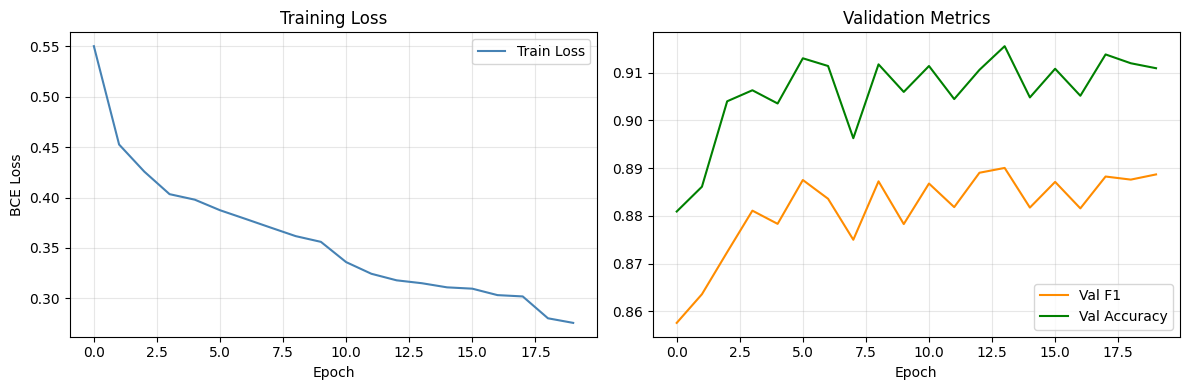

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="Train Loss", color="steelblue")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history["val_f1"],  label="Val F1",       color="darkorange")
axes[1].plot(history["val_acc"], label="Val Accuracy",  color="green")
axes[1].set_title("Validation Metrics")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

TEST SET RESULTS
              precision    recall  f1-score   support

     Non-FOG       0.92      0.93      0.93      5258
         FOG       0.91      0.90      0.91      4155

    accuracy                           0.92      9413
   macro avg       0.92      0.92      0.92      9413
weighted avg       0.92      0.92      0.92      9413



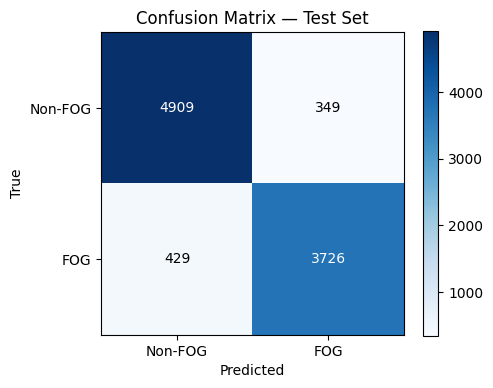

In [13]:
# Restore best weights
model.load_state_dict(best_state)
model.to(device)
model.eval()

all_preds, all_probs, all_labels = [], [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        logits  = model(X_batch)
        probs   = torch.sigmoid(logits).cpu()
        preds   = (probs > 0.5).float()

        all_probs.extend(probs.numpy())
        all_preds.extend(preds.numpy())
        all_labels.extend(y_batch.numpy())

all_preds  = np.array(all_preds).flatten()
all_probs  = np.array(all_probs).flatten()
all_labels = np.array(all_labels).flatten()

print("=" * 50)
print("TEST SET RESULTS")
print("=" * 50)
print(classification_report(all_labels, all_preds,
                             target_names=["Non-FOG", "FOG"]))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["Non-FOG", "FOG"])
ax.set_yticklabels(["Non-FOG", "FOG"])
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion Matrix — Test Set")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black")
plt.colorbar(im)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

In [15]:
def reconstruct_episodes(preds, t_starts, t_ends,
                          min_duration_s=0.5, merge_gap_s=1.0):
    """
    Convert per-window binary predictions → FOG episodes with start/end times.

    Args:
        preds         : binary array (N,)
        t_starts      : window start times in seconds (N,)
        t_ends        : window end times in seconds   (N,)
        min_duration_s: discard episodes shorter than this (noise filter)
        merge_gap_s   : merge consecutive FOG windows if gap < this threshold
    Returns:
        List of dicts: [{"start": float, "end": float, "duration": float}, ...]
    """
    episodes = []
    in_fog   = False
    ep_start = 0.0
    ep_end   = 0.0

    for i, pred in enumerate(preds):
        if pred == 1:
            if not in_fog:
                # Start a new episode
                ep_start = t_starts[i]
                ep_end   = t_ends[i]
                in_fog   = True
            else:
                # Check if gap from previous FOG window is small enough to merge
                gap = t_starts[i] - ep_end
                if gap <= merge_gap_s:
                    ep_end = t_ends[i]       # extend episode
                else:
                    # Gap too large — close current, start new
                    if (ep_end - ep_start) >= min_duration_s:
                        episodes.append({
                            "start":    round(float(ep_start), 3),
                            "end":      round(float(ep_end),   3),
                            "duration": round(float(ep_end - ep_start), 3)
                        })
                    ep_start = t_starts[i]
                    ep_end   = t_ends[i]
        else:
            if in_fog:
                if (ep_end - ep_start) >= min_duration_s:
                    episodes.append({
                        "start":    round(float(ep_start), 3),
                        "end":      round(float(ep_end),   3),
                        "duration": round(float(ep_end - ep_start), 3)
                    })
                in_fog = False

    # Close any open episode at the end
    if in_fog and (ep_end - ep_start) >= min_duration_s:
        episodes.append({
            "start":    round(float(ep_start), 3),
            "end":      round(float(ep_end),   3),
            "duration": round(float(ep_end - ep_start), 3)
        })

    return episodes


print("Episode reconstruction function ready.")

Episode reconstruction function ready.


In [16]:
unique_test_subjects = np.unique(subj_test)
all_episodes         = {}

for subj in unique_test_subjects:
    mask        = subj_test == subj
    subj_preds  = all_preds[mask]
    subj_starts = t_start_test[mask]
    subj_ends   = t_end_test[mask]

    # Sort by time (windows are ordered per subject already, but be safe)
    order       = np.argsort(subj_starts)
    subj_preds  = subj_preds[order]
    subj_starts = subj_starts[order]
    subj_ends   = subj_ends[order]

    episodes = reconstruct_episodes(
        subj_preds, subj_starts, subj_ends,
        min_duration_s=0.5,
        merge_gap_s=1.0
    )

    all_episodes[subj] = episodes

# Print results for first 5 subjects
print(f"{'Subject':<20} {'# Episodes':>12} {'Total FOG (s)':>15}")
print("-" * 50)
for subj in list(all_episodes.keys())[:5]:
    eps   = all_episodes[subj]
    total = sum(e["duration"] for e in eps)
    print(f"{subj:<20} {len(eps):>12} {total:>15.2f}")

    for ep in eps:
        print(f"    start: {ep['start']:>7.2f}s  "
              f"end: {ep['end']:>7.2f}s  "
              f"duration: {ep['duration']:.2f}s")

Subject                # Episodes   Total FOG (s)
--------------------------------------------------
011322847a                      4           10.00
    start:   10.00s  end:   11.50s  duration: 1.50s
    start:   12.00s  end:   16.50s  duration: 4.50s
    start:   17.00s  end:   19.50s  duration: 2.50s
    start:   28.00s  end:   29.50s  duration: 1.50s
024ba3ebd5                      2            3.00
    start:    7.00s  end:    8.50s  duration: 1.50s
    start:   24.00s  end:   25.50s  duration: 1.50s
02e8454f57                      0            0.00
02edc527c0                      1            1.50
    start:   20.00s  end:   21.50s  duration: 1.50s
06228cf84a                      2            4.00
    start:   20.00s  end:   21.50s  duration: 1.50s
    start:   23.00s  end:   25.50s  duration: 2.50s


In [17]:
# Save all episodes to CSV
rows = []
for subj, eps in all_episodes.items():
    for ep in eps:
        rows.append({
            "subject_id": subj,
            "start_s":    ep["start"],
            "end_s":      ep["end"],
            "duration_s": ep["duration"]
        })

episodes_df = pd.DataFrame(rows)
episodes_df.to_csv("fog_episodes.csv", index=False)
print(f"Saved {len(episodes_df)} episodes to fog_episodes.csv")
print(episodes_df.head(10))

# Save model weights
torch.save(best_state, "dl_fog_model_best.pth")
print("\nModel saved to dl_fog_model_best.pth")

# To reload later:
# model = FoGModel()
# model.load_state_dict(torch.load("fog_model_best.pth"))
# model.eval()

Saved 463 episodes to fog_episodes.csv
   subject_id  start_s  end_s  duration_s
0  011322847a     10.0   11.5         1.5
1  011322847a     12.0   16.5         4.5
2  011322847a     17.0   19.5         2.5
3  011322847a     28.0   29.5         1.5
4  024ba3ebd5      7.0    8.5         1.5
5  024ba3ebd5     24.0   25.5         1.5
6  02edc527c0     20.0   21.5         1.5
7  06228cf84a     20.0   21.5         1.5
8  06228cf84a     23.0   25.5         2.5
9  08cb8d3129     27.0   29.5         2.5

Model saved to dl_fog_model_best.pth


In [34]:
# ─────────────────────────────────────────
# 1. CONFIG — change these two paths only
# ─────────────────────────────────────────
CSV_PATH   = "/content/06228cf84a.csv"
MODEL_PATH = "dl_fog_model_best.pth"

FS          = 128
WINDOW_SIZE = 192
STEP        = 128
BATCH_SIZE  = 64

In [35]:
# ─────────────────────────────────────────
# 2. LOAD MODEL
# ─────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = FoGModel().to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()
print(f"Model loaded  |  device: {device}")

Model loaded  |  device: cpu


In [36]:
# ─────────────────────────────────────────
# 3. LOAD & VALIDATE CSV
# ─────────────────────────────────────────
df = pd.read_csv(CSV_PATH)

required_cols = ["AccV", "AccML", "AccAP"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"CSV is missing columns: {missing}")

print(f"Loaded {CSV_PATH}  |  rows: {len(df)}  "
      f"({len(df)/FS:.1f} s of data)")

Loaded /content/06228cf84a.csv  |  rows: 5908  (46.2 s of data)


In [37]:
# ─────────────────────────────────────────
# 4. SLIDING WINDOW EXTRACTION
# ─────────────────────────────────────────
signals  = df[["AccV", "AccML", "AccAP"]].values.astype(np.float32)
T        = len(signals)

windows, t_starts, t_ends = [], [], []

for start in range(0, T - WINDOW_SIZE, STEP):
    end = start + WINDOW_SIZE
    windows.append(signals[start:end])
    t_starts.append(start / FS)
    t_ends.append(end   / FS)

windows  = np.array(windows)           # (N, 192, 3)
t_starts = np.array(t_starts)
t_ends   = np.array(t_ends)

print(f"Total windows: {len(windows)}")

Total windows: 45


In [38]:

# ─────────────────────────────────────────
# 5. INFERENCE  (with per-window normalisation)
# ─────────────────────────────────────────
all_preds = []
all_probs = []

with torch.no_grad():
    for i in range(0, len(windows), BATCH_SIZE):
        batch = torch.tensor(windows[i:i+BATCH_SIZE])   # (B, 192, 3)

        # same normalisation as training
        mean  = batch.mean(dim=1, keepdim=True)
        std   = batch.std(dim=1,  keepdim=True) + 1e-8
        batch = (batch - mean) / std

        batch  = batch.to(device)
        logits = model(batch)
        probs  = torch.sigmoid(logits).cpu().numpy().flatten()
        preds  = (probs > 0.5).astype(int)

        all_probs.extend(probs)
        all_preds.extend(preds)

all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

print(f"FOG windows detected: {all_preds.sum()} / {len(all_preds)} "
      f"({all_preds.mean()*100:.1f}%)")

FOG windows detected: 4 / 45 (8.9%)


In [39]:


# ─────────────────────────────────────────
# 6. EPISODE RECONSTRUCTION
# ─────────────────────────────────────────
def reconstruct_episodes(preds, t_starts, t_ends,
                          min_duration_s=0.5, merge_gap_s=1.0):
    episodes = []
    in_fog   = False
    ep_start = ep_end = 0.0

    for i, pred in enumerate(preds):
        if pred == 1:
            if not in_fog:
                ep_start = t_starts[i]; ep_end = t_ends[i]; in_fog = True
            else:
                if t_starts[i] - ep_end <= merge_gap_s:
                    ep_end = t_ends[i]
                else:
                    if ep_end - ep_start >= min_duration_s:
                        episodes.append((ep_start, ep_end))
                    ep_start = t_starts[i]; ep_end = t_ends[i]
        else:
            if in_fog:
                if ep_end - ep_start >= min_duration_s:
                    episodes.append((ep_start, ep_end))
                in_fog = False

    if in_fog and ep_end - ep_start >= min_duration_s:
        episodes.append((ep_start, ep_end))

    return episodes


episodes = reconstruct_episodes(all_preds, t_starts, t_ends)

In [40]:
# ─────────────────────────────────────────
# 7. DISPLAY & SAVE RESULTS
# ─────────────────────────────────────────
print(f"\n{'='*45}")
print(f"  FOG EPISODES DETECTED: {len(episodes)}")
print(f"{'='*45}")
print(f"{'#':<5} {'Start (s)':>10} {'End (s)':>10} {'Duration (s)':>13}")
print("-" * 45)

for i, (start, end) in enumerate(episodes, 1):
    print(f"{i:<5} {start:>10.2f} {end:>10.2f} {end-start:>13.2f}")

total_fog = sum(e - s for s, e in episodes)
print("-" * 45)
print(f"Total FOG time : {total_fog:.2f} s")
print(f"Recording length: {T/FS:.2f} s")
print(f"FOG percentage : {total_fog/(T/FS)*100:.1f}%")

# Save to CSV
out_df = pd.DataFrame([
    {"episode":    i+1,
     "start_s":   round(s, 3),
     "end_s":     round(e, 3),
     "duration_s": round(e-s, 3)}
    for i, (s, e) in enumerate(episodes)
])

out_name = os.path.splitext(os.path.basename(CSV_PATH))[0] + "_fog_episodes.csv"
out_df.to_csv(out_name, index=False)
print(f"\nResults saved → {out_name}")


  FOG EPISODES DETECTED: 2
#      Start (s)    End (s)  Duration (s)
---------------------------------------------
1          19.00      21.50          2.50
2          23.00      25.50          2.50
---------------------------------------------
Total FOG time : 5.00 s
Recording length: 46.16 s
FOG percentage : 10.8%

Results saved → 06228cf84a_fog_episodes.csv
